**Problemática Abordada**

La empresa Riemax Inmobiliaria, una agencia con operaciones globales dedicada a la intermediación en la compra y venta de propiedades, enfrenta actualmente desafíos significativos en la gestión de su portafolio de transacciones. La información crítica sobre las propiedades listadas (ubicación, características, precio), las evaluaciones del entorno (índices de conectividad, calificaciones de vecindario) y los perfiles financieros de los clientes (salarios, montos de préstamos, decisiones finales) se encuentra fragmentada. Estos datos están dispersos en múltiples archivos de hojas de cálculo y reportes locales en diferentes oficinas internacionales, dificultando tener un inventario unificado y consultar el historial de operaciones de forma fiable.

**Objetivo**

Implementar una base de datos relacional centralizada para Riemax Inmobiliaria. El propósito principal es migrar e integrar toda la información histórica existente sobre las propiedades, las evaluaciones de entorno y las decisiones de compra de los clientes en esta nueva estructura unificada. Esta solución permitirá a la empresa organizar y consolidar sus registros, asegurando la integridad de los datos y mejorando la eficiencia en la gestión y consulta de la información operativa de las transacciones pasadas.

**Dataset** 


Nombre: Global House Purchase Decision Dataset
Fuente: Global Property Purchase Decision Dataset
Enlace: https://www.kaggle.com/datasets/mohankrishnathalla/global-house-purchase-decision-dataset?resource=download

**🎯 Variables Relevantes **

1. decision (Decisión)

Por qué es relevante: Es la variable clave para un análisis de clasificación. Te permite construir modelos para predecir si una futura solicitud de préstamo será aprobada (1) o rechazada (0), basándote en todas las demás variables financieras y de propiedad.

2. price (Precio)

Por qué es relevante: Es la variable objetivo para un análisis de regresión. Te permite entender qué factores (como el tamaño, la ubicación o el año de construcción) influyen más en el precio de una propiedad.

3. emi_to_income_ratio (Ratio EMI/Ingresos)

Por qué es relevante: Esta es quizás la variable financiera más potente. Mide la asequibilidad. Un banco no mira solo cuánto ganas (customer_salary) o cuánto pides (loan_amount), sino la relación entre ambos. Un ratio alto (ej. 50% de tu salario se va al préstamo) es un indicador de alto riesgo y probablemente predice un decision = 0.

4. customer_salary (Salario del Cliente)

Por qué es relevante: Es el pilar del análisis financiero. Determina el poder adquisitivo general. Es fundamental para predecir tanto el price de la vivienda que una persona puede permitirse como la decision final del préstamo.

5. property_size_sqft (Tamaño de la Propiedad)

Por qué es relevante: Es uno de los predictores físicos más directos del price. A mayor tamaño, casi siempre mayor precio (aunque la ubicación modera esto). También puede influir en la decision si el préstamo solicitado no se corresponde con el valor de una propiedad de ese tamaño.

6. neighbourhood_rating (Calificación del Vecindario)

Por qué es relevante: Esta variable captura el valor intangible de la "ubicación". Una calificación alta puede justificar un price elevado incluso para una propiedad pequeña (property_size_sqft) y puede dar más seguridad al banco para aprobar la decision, ya que la propiedad se considera una buena inversión (tiene buen valor de reventa).
 

In [0]:
!pip install kagglehub[pandas-datasets]>=0.3.8

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


##Importamos librerias

In [0]:
import kagglehub
import pandas as pd
import os
import zipfile

Creamos Funciones para Descargar, Extraer y el Leer el Dataset de Kaggle.

In [0]:
def download_dataset_zip(url = ""):
        print("Descargando dataset desde Kaggle...")
        dataset_path = kagglehub.dataset_download(url)
        print("Ruta al dataset:", dataset_path)
        return dataset_path
    
def extract_zip_files(dataset_path):
        zip_files = [f for f in os.listdir(dataset_path) if f.endswith('.zip')]
        if zip_files:
            zip_file = os.path.join(dataset_path, zip_files[0])
            extract_dir = os.path.join(dataset_path, "extracted")
            os.makedirs(extract_dir, exist_ok=True)
            print(f"Extrayendo {zip_file} en {extract_dir}...")
            with zipfile.ZipFile(zip_file, "r") as z:
                z.extractall(extract_dir)
            return extract_dir
        else:
            # Si no se encuentra un ZIP, se verifica si existen archivos CSV en la ruta
            csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
            if csv_files:
                print("No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.")
                return dataset_path
            else:
                raise FileNotFoundError("No se encontró ningún archivo .zip ni archivos .csv en la ruta del dataset")

def create_csv(csv_dir, csv_name=None):
    if csv_name:
        file_path = os.path.join(csv_dir, csv_name)
        print(f"Leyendo {file_path}...")
        df = pd.read_csv(file_path, encoding="latin1")
        print("CSV creado correctamente")
        return df
    else:
        csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]
        if not csv_files:
            raise FileNotFoundError("No se encontraron archivos CSV en el directorio extraído")
        for file in csv_files:
            file_path = os.path.join(csv_dir, file)
            print(f"Leyendo {file_path}...")
            df = pd.read_csv(file_path, encoding="latin1")
        print("CSV creado correctamente")
        return df


Descargamos dataset

In [0]:
df = pd.DataFrame()
dataset_path = download_dataset_zip("mohankrishnathalla/global-house-purchase-decision-dataset") 
csv_dir = extract_zip_files(dataset_path)
df = create_csv(csv_dir)

Descargando dataset desde Kaggle...


100%|██████████| 7.42M/7.42M [00:00<00:00, 11.8MB/s]

Extracting files...


Ruta al dataset: /home/spark-1fae12af-dbe7-49bd-b7db-98/.cache/kagglehub/datasets/mohankrishnathalla/global-house-purchase-decision-dataset/versions/1
No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.
Leyendo /home/spark-1fae12af-dbe7-49bd-b7db-98/.cache/kagglehub/datasets/mohankrishnathalla/global-house-purchase-decision-dataset/versions/1/global_house_purchase_dataset.csv...
CSV creado correctamente


Validamos DF

In [0]:
df.head(5)

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,legal_cases_on_property,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,2,1,1,1,0,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,8,1,1,1,1,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,1,1,1,0,0,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,3,0,1,0,0,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,3,1,1,3,1,17676,65833,25,8965,33208,0.03,3,3,4,0


Convertimos de pandas a Spark

In [0]:
spark_df = spark.createDataFrame(df)

Creamos la Tabla e Insertamos datos

In [0]:
spark_df.write.mode("overwrite").saveAsTable("tbl_ventas_viviendas")

Verificamos la creación de la tabla con sus variables

In [0]:
%sql
DESCRIBE TABLE tbl_ventas_viviendas;

col_name,data_type,comment
property_id,bigint,null
country,string,null
city,string,null
property_type,string,null
furnishing_status,string,null
property_size_sqft,bigint,null
price,bigint,null
constructed_year,bigint,null
previous_owners,bigint,null
rooms,bigint,null


Contamos 10 registros

In [0]:
%sql
SELECT * 
FROM tbl_ventas_viviendas
LIMIT 10;
     

property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,legal_cases_on_property,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,2,1,1,1,0,10745,193949,15,6545,218986,0.16,1,5,6,0
2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,8,1,1,1,1,16970,181465,20,8605,43073,0.08,9,1,2,0
3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,1,1,1,0,0,21914,307953,30,2510,437151,0.09,6,8,1,0
4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,3,0,1,0,0,17980,674720,15,8805,436239,0.33,2,6,6,0
5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,3,1,1,3,1,17676,65833,25,8965,33208,0.03,3,3,4,0
6,Canada,Montreal,Villa,Semi-Furnished,3169,1107368,1985,0,5,2,1,0,0,0,95520,793316,30,10615,314052,0.05,10,8,2,1
7,Brazil,Rio de Janeiro,Studio,Unfurnished,1986,398439,1976,1,2,1,1,0,0,0,11426,268167,25,14440,130272,0.16,9,10,10,1
8,Brazil,SÃ£o Paulo,Townhouse,Semi-Furnished,4048,807236,2020,4,6,6,1,1,1,0,29832,503385,20,7200,303851,0.13,1,5,8,0
9,UAE,Dubai,Farmhouse,Semi-Furnished,5213,3131373,1968,6,2,1,0,0,0,0,56255,1866416,15,10300,1264957,0.29,8,8,10,1
10,Australia,Melbourne,Apartment,Unfurnished,4648,1483250,1966,2,5,2,0,1,0,1,67350,1093290,10,16360,389960,0.18,1,4,7,0


Conteo de Propiedades por País

In [0]:
%sql
SELECT
    country,
    COUNT(property_id) AS total_propiedades
FROM
    tbl_ventas_viviendas
GROUP BY
    country
ORDER BY
    total_propiedades DESC;

country,total_propiedades
France,15628
China,15536
Australia,15442
UK,15413
Germany,15408
Canada,15401
South Africa,15401
Brazil,15397
India,15357
Japan,15317


Cuenta cuántas propiedades (viviendas) hay registradas en tu base de datos para cada país y las ordena de mayor a menor.

Propiedades más Caras

In [0]:
%sql
SELECT
    property_id,
    city,
    price
FROM
    tbl_ventas_viviendas
ORDER BY
    price DESC
LIMIT 10;

property_id,city,price
149437,Singapore,4202732
145267,Singapore,4202721
70487,Singapore,4202151
16744,Singapore,4201912
166138,Singapore,4201277
68167,Singapore,4201197
21063,Singapore,4200900
85180,Singapore,4200894
77251,Singapore,4199892
178596,Singapore,4198888


Muestra el ID, la ciudad y el precio de las 10 viviendas más caras de todo el dataset.

Propiedades donde la Compra fue Aprobada

Selecciona todas las columnas de las filas donde la compra fue exitosa (asumiendo que decision = 1 significa "aprobado", según el dataset).

In [0]:
%sql
SELECT
    property_type,
    AVG(price) AS precio_promedio
FROM
    tbl_ventas_viviendas
GROUP BY
    property_type;

property_type,precio_promedio
Townhouse,1216972.455217847
Farmhouse,1220261.5798078645
Studio,1212892.1994970916
Apartment,1216839.2162404933
Villa,1211266.50346358
Independent House,1213903.4250314995


In [0]:
import sys

Creamos el catalogo 

In [0]:
%sql
-- 1. Crear el Catálogo principal 
CREATE CATALOG IF NOT EXISTS viviendas;

-- 2. Crear el Esquema de Viviendas (base de datos)
CREATE SCHEMA IF NOT EXISTS viviendas.ventas_schema;

-- 3. Crear el Volume para almacenar archivos no tabulares,

CREATE VOLUME IF NOT EXISTS viviendas.ventas_schema.vol_ventas;

DESCRIBE LA TABLA


In [0]:
%sql
DESCRIBE TABLE tbl_ventas_viviendas;

col_name,data_type,comment
property_id,bigint,null
country,string,null
city,string,null
property_type,string,null
furnishing_status,string,null
property_size_sqft,bigint,null
price,bigint,null
constructed_year,bigint,null
previous_owners,bigint,null
rooms,bigint,null


Describimos la tabla

In [0]:
%sql
SHOW TABLES IN viviendas.ventas_schema;

database,tableName,isTemporary


In [0]:
%sql
SHOW TABLES IN viviendas.ventas_schema;



database,tableName,isTemporary


In [0]:
nombre_catalogo = "Ventas_Viviendas"
schemas = ["Ventas","Vidiendas"]
spark.sql("create CATALOG if not exists {}".format(nombre_catalogo))

DataFrame[]

In [0]:
%sql
create CATALOG if not exists ventas_viviendas;

In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS {}.{}".format(nombre_catalogo,schemas[0]))
spark.sql("CREATE SCHEMA IF NOT EXISTS {}.{}".format(nombre_catalogo,schemas[1]))
#spark.sql("show SCHEMA {}.{}".format(nombre_catalogo,schemas[2]))
#spark.sql("SHOW TABLES")

DataFrame[]

In [0]:
nomtabla= "tbl_viviendas"
df = spark.read.format("csv").option("header","true").option("inferSchema","true").load("/Volumes/workspace/bigdata/semana3/ventas_viviendas.csv")


Actividad 3: Transformación, Limpieza y Visualización en Databricks
Estudiante: Alejandro Cadavid 
Dataset: Global House Purchase

In [0]:
%sql
SHOW TABLES;

database,tableName,isTemporary
default,tbl_ventas_viviendas,false


Configuración e Ingesta de Datos (Desde Tabla)

In [0]:

nombre_tabla = "tbl_ventas_viviendas" 

try:
    # Cargamos directamente desde la tabla gestionada por Databricks
    df = spark.table(nombre_tabla)
    
    print(f"✅ ¡Tabla '{nombre_tabla}' cargada exitosamente!")
    print(f"Total de registros: {df.count()}")
    display(df.limit(5))

except Exception as e:
    print(f"❌ Error: No se encuentra la tabla '{nombre_tabla}'.")
    print("Verifica el nombre ejecutando '%sql SHOW TABLES' en la celda anterior.")

✅ ¡Tabla 'tbl_ventas_viviendas' cargada exitosamente!
Total de registros: 200000


property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,legal_cases_on_property,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
25001,Germany,Frankfurt,Farmhouse,Fully-Furnished,3890,1165605,1988,6,1,1,0,1,1,0,80340,970267,25,5355,195338,0.08,7,10,2,1
25002,UK,Birmingham,Townhouse,Fully-Furnished,2862,1141712,2005,0,5,5,0,1,1,0,70950,585272,30,2580,556440,0.05,10,4,1,1
25003,India,Chennai,Townhouse,Semi-Furnished,5642,848469,2002,5,4,2,0,1,1,0,5684,566190,20,3131,282279,0.74,5,7,8,0
25004,UK,Birmingham,Independent House,Semi-Furnished,2275,910391,2004,2,3,3,1,1,0,0,52695,766145,20,9245,144246,0.11,9,6,4,1
25005,Brazil,SÃ£o Paulo,Studio,Fully-Furnished,4333,866338,2012,5,2,2,0,1,1,0,25290,487135,20,5085,379203,0.14,6,10,2,0


Configuración e Ingesta de Datos

In [0]:
# Definimos el nombre de la tabla
nombre_tabla = "tbl_ventas_viviendas"

try:
    # Cargamos el DataFrame directamente desde la tabla de Databricks
    df = spark.table(nombre_tabla)
    
    print(f"✅ ¡Conexión exitosa con la tabla '{nombre_tabla}'!")
    print(f"Total de registros: {df.count()}")
    
    # Mostramos las primeras filas para verificar
    display(df.limit(5))

except Exception as e:
    print("❌ Error: No se pudo leer la tabla.")
    print(f"Verifica que '{nombre_tabla}' aparezca al ejecutar '%sql SHOW TABLES'")
    print(f"Detalle del error: {e}")

✅ ¡Conexión exitosa con la tabla 'tbl_ventas_viviendas'!
Total de registros: 200000


property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,legal_cases_on_property,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
25001,Germany,Frankfurt,Farmhouse,Fully-Furnished,3890,1165605,1988,6,1,1,0,1,1,0,80340,970267,25,5355,195338,0.08,7,10,2,1
25002,UK,Birmingham,Townhouse,Fully-Furnished,2862,1141712,2005,0,5,5,0,1,1,0,70950,585272,30,2580,556440,0.05,10,4,1,1
25003,India,Chennai,Townhouse,Semi-Furnished,5642,848469,2002,5,4,2,0,1,1,0,5684,566190,20,3131,282279,0.74,5,7,8,0
25004,UK,Birmingham,Independent House,Semi-Furnished,2275,910391,2004,2,3,3,1,1,0,0,52695,766145,20,9245,144246,0.11,9,6,4,1
25005,Brazil,SÃ£o Paulo,Studio,Fully-Furnished,4333,866338,2012,5,2,2,0,1,1,0,25290,487135,20,5085,379203,0.14,6,10,2,0


In [0]:
# Importaciones globales para todo el notebook
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, DoubleType

# Nombre de la tabla
nombre_tabla = "tbl_ventas_viviendas"

try:
    # Cargar desde la tabla gestionada
    df = spark.table(nombre_tabla)
    print(f"✅ Conexión exitosa. Total de registros: {df.count()}")
    display(df.limit(5))
except Exception as e:
    print(f"❌ Error: No se encuentra la tabla '{nombre_tabla}'. Verifica el nombre.")

✅ Conexión exitosa. Total de registros: 200000


property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,legal_cases_on_property,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
25001,Germany,Frankfurt,Farmhouse,Fully-Furnished,3890,1165605,1988,6,1,1,0,1,1,0,80340,970267,25,5355,195338,0.08,7,10,2,1
25002,UK,Birmingham,Townhouse,Fully-Furnished,2862,1141712,2005,0,5,5,0,1,1,0,70950,585272,30,2580,556440,0.05,10,4,1,1
25003,India,Chennai,Townhouse,Semi-Furnished,5642,848469,2002,5,4,2,0,1,1,0,5684,566190,20,3131,282279,0.74,5,7,8,0
25004,UK,Birmingham,Independent House,Semi-Furnished,2275,910391,2004,2,3,3,1,1,0,0,52695,766145,20,9245,144246,0.11,9,6,4,1
25005,Brazil,SÃ£o Paulo,Studio,Fully-Furnished,4333,866338,2012,5,2,2,0,1,1,0,25290,487135,20,5085,379203,0.14,6,10,2,0


1. Transformaciones: Columnas de Fecha
Como el dataset original no tiene fecha, generamos una secuencia temporal simulada (empezando en 2023) y derivamos las columnas requeridas.

In [0]:
# --- Generación de Fecha Artificial ---
fecha_base = F.to_date(F.lit("2023-01-01"))
ventana = Window.orderBy(F.monotonically_increasing_id())

# Creamos ID y sumamos días (usando cast a int para evitar errores)
df_con_fecha = df.withColumn("rn", F.row_number().over(ventana)) \
                 .withColumn("fecha", F.date_add(fecha_base, (F.col("rn") - 1).cast("int"))) \
                 .drop("rn")

# --- Derivación de Columnas de Tiempo ---
df_transformado = (df_con_fecha
  .withColumn("anio", F.year("fecha"))
  .withColumn("mes", F.month("fecha"))
  .withColumn("dia", F.dayofmonth("fecha"))
  .withColumn("dia_semana", F.date_format("fecha", "u").cast("int")) # 1=Lunes
  .withColumn("nombre_dia", F.date_format("fecha", "EEEE"))          # Nombre día
)

print("✅ Columnas de fecha generadas.")
display(df_transformado.select("property_id", "fecha", "anio", "mes", "nombre_dia").limit(5))

✅ Columnas de fecha generadas.


property_id,fecha,anio,mes,nombre_dia
1,2023-01-01,2023,1,Sunday
2,2023-01-02,2023,1,Monday
3,2023-01-03,2023,1,Tuesday
4,2023-01-04,2023,1,Wednesday
5,2023-01-05,2023,1,Thursday


2. Nueva Tabla: Resumen Mensual (SQL)
Creamos una vista temporal y usamos SQL para generar una tabla agregada.

In [0]:
# Registramos el DF como vista temporal para poder usar SQL
df_transformado.createOrReplaceTempView("v_ventas_transformada")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
%sql
-- Creación de la tabla resumen
CREATE OR REPLACE TEMP VIEW resumen_mensual AS
SELECT 
  anio, 
  mes,
  COUNT(*) as total_ventas,
  ROUND(AVG(price), 2) as precio_promedio,
  ROUND(AVG(satisfaction_score), 2) as satisfaccion_promedio
FROM v_ventas_transformada
GROUP BY anio, mes
ORDER BY anio, mes;

-- Evidencia
SELECT * FROM resumen_mensual LIMIT 12;

anio,mes,total_ventas,precio_promedio,satisfaccion_promedio
2023,1,31,1387231.06,4.9
2023,2,28,1361484.11,5.0
2023,3,31,1187068.23,6.26
2023,4,30,1063907.27,5.83
2023,5,31,1122432.58,5.23
2023,6,30,1142563.27,5.77
2023,7,31,1189207.68,5.42
2023,8,31,1241994.35,5.19
2023,9,30,1198370.3,6.03
2023,10,31,1197029.42,4.84


3. Limpieza: Evidencia Antes/Después
Aplicamos normalización de texto y eliminación de outliers en el precio.

In [0]:
# --- Estado ANTES ---
df_before = df_transformado

# --- PROCESO DE LIMPIEZA ---

# 1. Normalización de texto (Trim y Lower) en el tipo de propiedad
df_clean = df_transformado.withColumn("tipo_propiedad_limpio", F.lower(F.trim(F.col("property_type"))))

# 2. Casteo seguro de precio
df_clean = df_clean.withColumn("price", F.col("price").cast(DoubleType()))

# 3. Eliminación de Outliers (Precios extremos) usando IQR
quantiles = df_clean.approxQuantile("price", [0.25, 0.75], 0.01)
Q1, Q3 = quantiles[0], quantiles[1]
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtramos
df_final = df_clean.filter((F.col("price") >= limite_inferior) & (F.col("price") <= limite_superior))

# --- EVIDENCIAS ---
print("--- Comparativa de Registros ---")
print(f"Registros Antes: {df_before.count()}")
print(f"Registros Después: {df_final.count()}")

print("\n--- Muestra Antes (Texto original) ---")
display(df_before.select("property_type", "price").limit(3))

print("\n--- Muestra Después (Texto normalizado) ---")
display(df_final.select("tipo_propiedad_limpio", "price").limit(3))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


--- Comparativa de Registros ---
Registros Antes: 200000
Registros Después: 196369

--- Muestra Antes (Texto original) ---


property_type,price
Farmhouse,412935
Apartment,224538
Farmhouse,745104



--- Muestra Después (Texto normalizado) ---


tipo_propiedad_limpio,price
farmhouse,412935.0
apartment,224538.0
farmhouse,745104.0


Justificación: La normalización estandariza categorías (ej: "Apartment " vs "apartment"). El filtro de outliers elimina propiedades con precios anormalmente altos que distorsionarían el promedio del mercado.

4. Visualizaciones (Python: Matplotlib/Seaborn)
Convertimos una muestra a Pandas para graficar.

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/home/spark-b98eadcb-538a-434e-a22a-8c/.ipykernel/2352/command-6829237575044213-1328284184:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="tipo_propiedad_limpio", y="price", data=pdf, palette="viridis", errorbar=None)


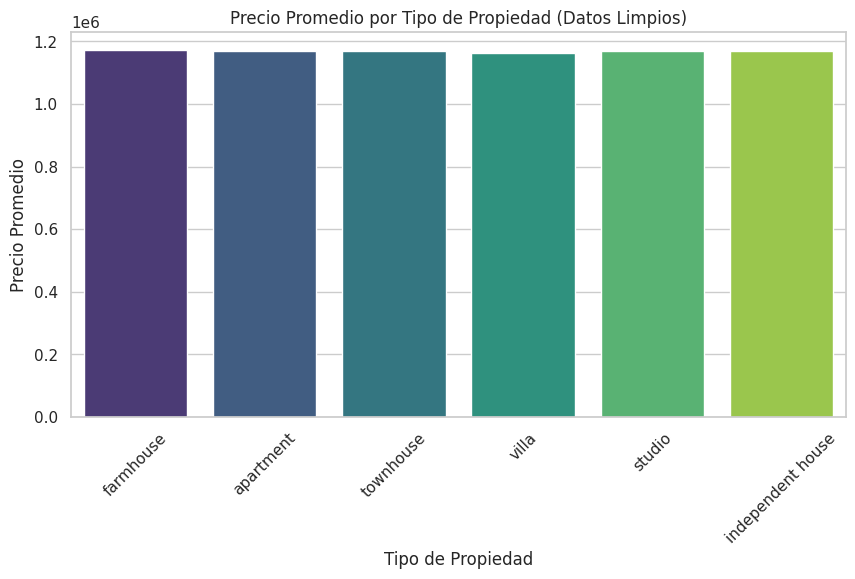

/home/spark-b98eadcb-538a-434e-a22a-8c/.ipykernel/2352/command-6829237575044213-1328284184:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="furnishing_status", y="satisfaction_score", data=pdf, palette="Set2")


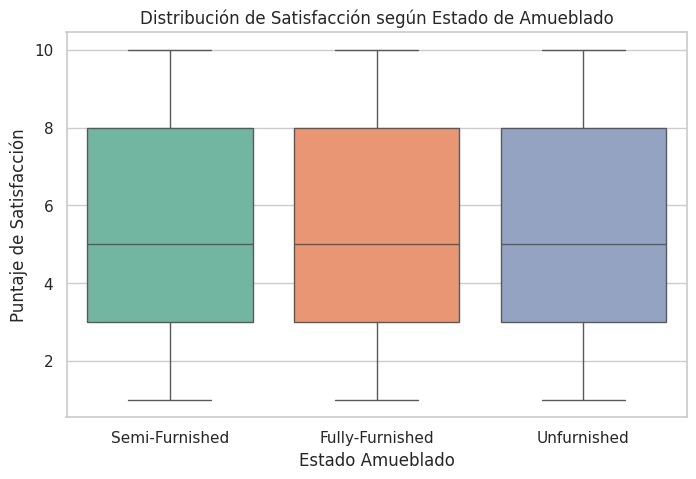

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertimos a Pandas para graficar (Usamos una muestra si son muchos datos, o todo si cabe)
pdf = df_final.select("tipo_propiedad_limpio", "price", "satisfaction_score", "furnishing_status", "anio").toPandas()

# Configuración estética
sns.set(style="whitegrid")

# --- GRÁFICO 1: Precio por Tipo de Propiedad ---
plt.figure(figsize=(10, 5))
sns.barplot(x="tipo_propiedad_limpio", y="price", data=pdf, palette="viridis", errorbar=None)
plt.title("Precio Promedio por Tipo de Propiedad (Datos Limpios)")
plt.xlabel("Tipo de Propiedad")
plt.ylabel("Precio Promedio")
plt.xticks(rotation=45)
plt.show()

# --- GRÁFICO 2: Satisfacción vs Amueblado ---
plt.figure(figsize=(8, 5))
sns.boxplot(x="furnishing_status", y="satisfaction_score", data=pdf, palette="Set2")
plt.title("Distribución de Satisfacción según Estado de Amueblado")
plt.xlabel("Estado Amueblado")
plt.ylabel("Puntaje de Satisfacción")
plt.show()

Interpretación:

Barras: Nos permite identificar rápidamente cuál es el tipo de vivienda más costoso en promedio.

Boxplot: Nos muestra la dispersión de la satisfacción del cliente; por ejemplo, si las casas totalmente amuebladas tienden a tener puntajes más altos y consistentes.